In [5]:
import pandas as pd

df = pd.read_csv("NABIL.csv")
print(df.head())
print(df.info())
print(df.describe())

  published_date    open    high     low   close  per_change  traded_quantity  \
0     2011-05-15  1091.0  1155.0  1112.0  1155.0         NaN             38.0   
1     2011-05-16  1155.0  1193.0  1160.0  1193.0        3.29            156.0   
2     2011-05-18  1193.0  1172.0  1150.0  1172.0       -1.76            939.0   
3     2011-05-19  1172.0  1194.0  1155.0  1194.0        1.88            490.0   
4     2011-05-22  1194.0  1193.0  1178.0  1178.0       -1.34            115.0   

   traded_amount  status  
0        43057.0       0  
1       183026.0       0  
2      1087972.0       0  
3       573992.0       0  
4       135930.0       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3398 entries, 0 to 3397
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   published_date   3398 non-null   object 
 1   open             3398 non-null   float64
 2   high             3398 non-null   float64
 3   low       

In [8]:
df["published_date"] = pd.to_datetime(df["published_date"])
df = df.sort_values("published_date")
df = df.set_index("published_date")

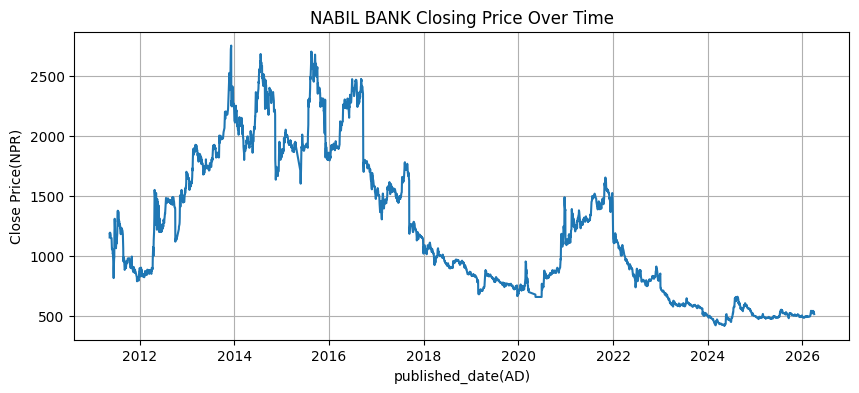

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(df["close"])
plt.title("NABIL BANK Closing Price Over Time")
plt.xlabel("published_date(AD)")
plt.ylabel("Close Price(NPR)")
plt.grid(True)
plt.show()

In [12]:
df["MA_5"] = df["close"].rolling(window=5).mean()
df["MA_20"] = df["close"].rolling(window=20).mean()
df = df.dropna()  

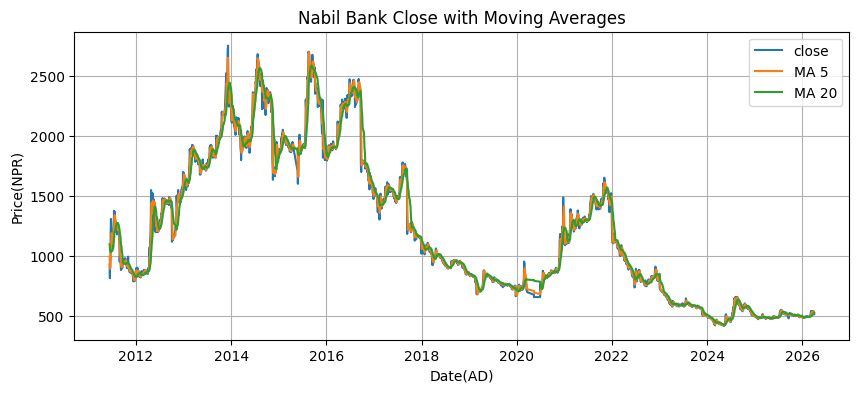

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(df["close"], label="close")
plt.plot(df["MA_5"], label="MA 5")
plt.plot(df["MA_20"], label="MA 20")
plt.title("Nabil Bank Close with Moving Averages")
plt.xlabel("Date(AD)")
plt.ylabel("Price(NPR)")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
df["Return_1d"] = df["close"].pct_change()
df["Target_Up"] = (df["close"].shift(-1) > df["close"]).astype(int)
df = df.dropna()

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

features = ["MA_5", "MA_20", "Return_1d"]
X = df[features]
y = df["Target_Up"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # keep time order
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.63      0.10      0.18       416
           1       0.39      0.90      0.54       260

    accuracy                           0.41       676
   macro avg       0.51      0.50      0.36       676
weighted avg       0.54      0.41      0.32       676



In [19]:
df["Volume"] = df["traded_quantity"]
df["Turnover"] = df["traded_amount"]

df["Vol_MA_5"] = df["Volume"].rolling(5).mean()
df["Vol_MA_20"] = df["Volume"].rolling(20).mean()

df = df.dropna()

In [21]:
features = ["MA_5", "MA_20", "Return_1d", "Vol_MA_5", "Vol_MA_20"]
X = df[features]

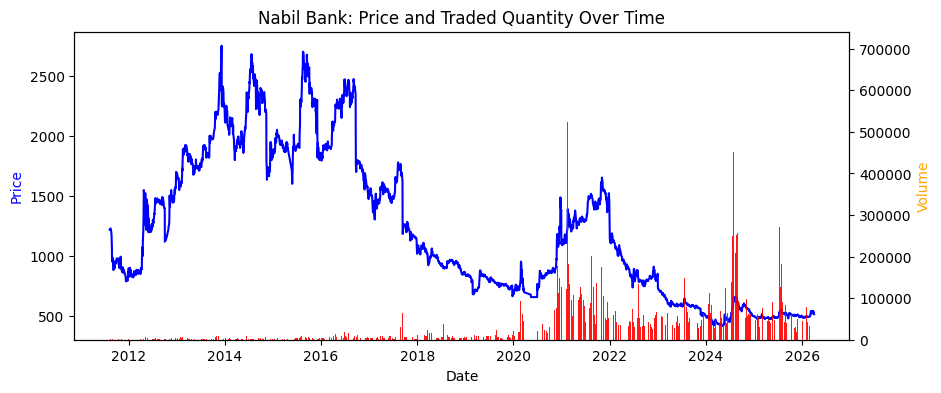

In [23]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(df.index, df["close"], color="blue", label="Close Price")
ax1.set_xlabel("Date")
ax1.set_ylabel("Price", color="blue")

ax2 = ax1.twinx()
ax2.bar(df.index, df["Volume"], alpha=0.9, color="RED", label="Traded Quantity")
ax2.set_ylabel("Volume", color="orange")

plt.title("Nabil Bank: Price and Traded Quantity Over Time")
plt.show()

In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 0.5171153846153846


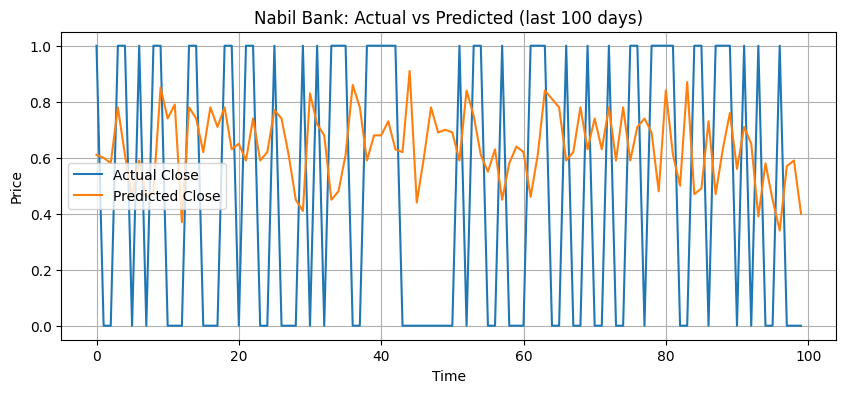

In [29]:
n = 100  # last 100 days
actual = y_test.values[-n:]
pred = y_pred[-n:]

plt.figure(figsize=(10,4))
plt.plot(actual, label="Actual Close")
plt.plot(pred, label="Predicted Close")
plt.title("Nabil Bank: Actual vs Predicted (last 100 days)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

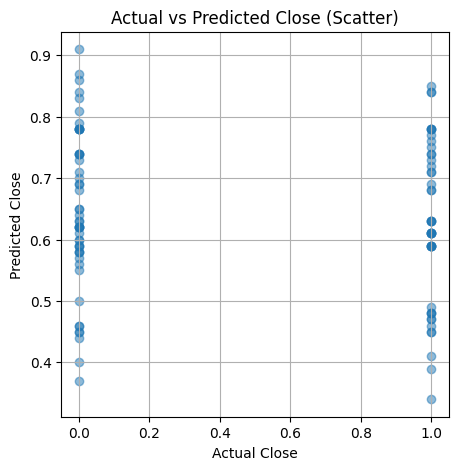

In [30]:
plt.figure(figsize=(5,5))
plt.scatter(actual, pred, alpha=0.5)
plt.xlabel("Actual Close")
plt.ylabel("Predicted Close")
plt.title("Actual vs Predicted Close (Scatter)")
plt.grid(True)
plt.show()